# Week 2 Session 3: Class Activities

Warm-up review of regression, then a gentle introduction to classification.

## Activities in this Session

| # | Activity | Models | Dataset |
|---|----------|--------|---------|
| 1 | Regression Review | Linear, Polynomial, Ridge, Lasso | `1000_Companies.csv` |
| 2 | Classification | Logistic (binary + multiclass), SVM, Decision Tree | `winequality-red.csv` |
| 3 | Classification | Logistic multiclass, SVM, Decision Tree | `ai_job_dataset.csv` |

Each activity block below has a short **Activity Card** explaining the task, dataset, and target. Complete the **TODO** sections.


In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, confusion_matrix, classification_report)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)


---
# Activity 1 -- Regression Review

> ### Activity Card
> **Goal:** Comparing Linear, Polynomial, Ridge, and Lasso regression on the same dataset.
> **Dataset:** `1000_Companies.csv` -- financial records for 1000 companies.
> **Features (X):** `R&D Spend`, `Administration`, `Marketing Spend`, `State` (categorical)
> **Target (y):** `Profit`
> **Task:** Train four regression models and compare their R-squared and RMSE on the test set.

You saw these models in Week 1 -- this activity is a quick refresher before we move to classification.


In [219]:
# Load the dataset
companies = pd.read_csv('../../Datasets/1000_Companies.csv')

# Display basic information about the dataset
print('Shape:', companies.shape)

# Display the first few rows of the dataset
display(companies.head())



Shape: (1000, 5)


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [220]:
# train-test split
X = companies.drop('Profit', axis=1)
y = companies['Profit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Preprocessing: Encode categorical variable and scale features
le = LabelEncoder()
X_train['State'] = le.fit_transform(X_train['State'])
X_test['State'] = le.transform(X_test['State'])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)
# Predict and evaluate the model
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.2f}')    

Mean Squared Error: 30259162.76
R² Score: 0.98


In [221]:
# Preprocessing: One-hot encode the 'State' column: What does it mean? 
# One-hot encoding is a technique used to convert categorical variables into a format that can be provided to machine learning algorithms to improve predictions. 
# It creates new binary columns for each category in the original column, where each column represents a category and contains 1 if the category is present and 0 otherwise. 
# In this case, the 'State' column will be transformed into multiple columns (e.g., 'State_California', 'State_Florida', 'State_New York'), with binary values indicating the presence of each state in the dataset.

companies_enc = pd.get_dummies(companies, columns=['State'], drop_first=False, dtype=int)

# Display the first few rows of the dataset
display(companies_enc.head())


# Train-test split: Target variable is 'Profit' and the rest are features.
X = companies_enc.drop('Profit', axis=1)
y = companies_enc['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features: Scaling is a technique used to standardize the range of independent variables or features of data. 
# It is important because many machine learning algorithms perform better when the features are on a similar scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train size: {X_train.shape}  |  Test size: {X_test.shape}')


,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,0,1
1,162597.70,151377.59,443898.53,191792.06,1,0,0
2,153441.51,101145.55,407934.54,191050.39,0,1,0
3,144372.41,118671.85,383199.62,182901.99,0,0,1
4,142107.34,91391.77,366168.42,166187.94,0,1,0


Train size: (800, 6)  |  Test size: (200, 6)


### 1.1 Linear Regression (baseline)

In [222]:
# TODO: Train a Linear Regression model
model = LinearRegression()


# TODO: Predict and evaluate the model



### 1.2 Polynomial Regression (degree 2)

Polynomial regression adds squared and interaction terms, letting a linear model fit curved relationships.

In [223]:

# TODO: Train a Polynomial Regression model with degree=2 and evaluate it

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform the scaled features into polynomial features
X_train_p = poly.fit_transform(X_train_s)
X_test_p  = poly.transform(X_test_s)

# TODO: Train a Linear Regression model on the polynomial features
model_poly = LinearRegression()


# TODO: Predict and evaluate the polynomial regression model




### 1.3 Ridge Regression

Ridge adds an L2 penalty on large coefficients. Controlled by `alpha` -- higher alpha = more shrinkage.

##### What is Ridge Regression and how does it differ from Linear Regression?
Ridge Regression is a type of linear regression that includes a regularization term (L2 penalty)
It adds a penalty to the loss function based on the magnitude of the coefficients, which helps to prevent overfitting by shrinking the coefficients towards zero.
In contrast, Linear Regression does not include any regularization and may lead to overfitting if the model is too complex or if there are many features.
Ridge regression can be particularly useful when dealing with multicollinearity (when independent variables are highly correlated) or when the number of features is greater than the number of observations, as it can help to stabilize the estimates and improve the generalization of the model.


In [224]:
# TODO: Train a Ridge Regression model with alpha=1.0 and evaluate it
model_ridge = Ridge(alpha=1.0)

# TODO: Predict and evaluate the Ridge Regression model



### 1.4 Lasso Regression

Lasso uses an L1 penalty that can shrink coefficients all the way to zero -- effectively doing feature selection.

#### What is Lasso Regression and how does it differ from Ridge Regression?
Lasso Regression (Least Absolute Shrinkage and Selection Operator) is a linear regression technique that uses L1 regularization to prevent overfitting and perform feature selection. 
It adds a penalty equal to the absolute value of the magnitude of coefficients to the loss function. 
This penalty can shrink some coefficients to zero, effectively removing those features from the model, which is why Lasso can be used for feature selection. 
In contrast, Ridge Regression uses L2 regularization, which adds a penalty equal to the square of the magnitude of coefficients. 
Ridge can shrink coefficients but does not set any of them to zero, so it does not perform feature selection.

In [225]:
# TODO: Train a Lasso Regression model with alpha=100 and evaluate it
model_lasso = Lasso(alpha=100)


# TODO: Predict and evaluate the Lasso Regression model


### 1.5 Compare the Four Models

In [226]:
# TODO: Compare the results of all models and visualize the predictions vs actual values for the best model

# TODO: Visualize the coefficients of the best model to understand feature importance

# TODO: Visualize the residuals of the best model to check for patterns and assumptions of linear regression

# TODO: Create a scatter plot of residuals vs predicted values


### More Activities

1. Try `Ridge(alpha=10)` and `Ridge(alpha=0.01)`. How does alpha affect R-squared?
2. Try `Lasso(alpha=500)`. How many coefficients become zero?
3. Try `PolynomialFeatures(degree=3)`. Does it beat degree 2, or start to overfit?


In [227]:
# TODO:


---
# Activity 2 -- Classification on Wine Quality

We will use the **red wine quality** dataset for four small classification tasks.

**Shared context for Activities 2a-2d:**
- **Dataset:** `winequality-red.csv` (1599 rows, 11 chemical features, quality score)
- **Features (X):** `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`
- **Note:** the CSV uses `;` as the separator.

We will build the target in two forms:
- A **binary** target (good / not good) for 2a
- A **multiclass** target (low / medium / high) for 2b, 2c, 2d


In [228]:
# Load the wine quality dataset
wine = pd.read_csv('../../Datasets/winequality-red.csv', sep=';')

# Display basic information about the dataset
print('Shape:', wine.shape)
print('\nQuality distribution:')
print(wine['quality'].value_counts().sort_index())

display(wine.head())


Shape: (1599, 12)

Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [229]:
# Feature matrix -- shared across activities 2a-2d
# We will use the same features for all activities, but different target variables.
# The feature matrix X_wine will contain all columns except 'quality', which is the target variable.
# We will create two different target variables for the classification tasks:
# 1. Binary target: 1 if quality >= 7 ('good'), else 0
# 2. Multiclass target: low / medium / high based on quality

# Create the feature matrix by selecting all columns except 'quality'
feature_cols = [c for c in wine.columns if c != 'quality']
X_wine = wine[feature_cols]

# --- Binary target: 1 if quality >= 7 ('good'), else 0 ---
# Create the binary target variable
y_bin = (wine['quality'] >= 7).astype(int)

# --- Multiclass target: low / medium / high ---
# Define a function to bin the quality scores into low, medium, and high categories
def bin_quality(q):
    if q <= 4:
        return 'low'
    if q <= 6:
        return 'medium'
    return 'high'

# Create the multiclass target variable
y_multi = wine['quality'].apply(bin_quality)

# Display the class counts for both binary and multiclass targets
print('Binary class counts:')
print(y_bin.value_counts())
print('\nMulticlass counts:')
print(y_multi.value_counts())


Binary class counts:
quality
0    1382
1     217
Name: count, dtype: int64

Multiclass counts:
quality
medium    1319
high       217
low         63
Name: count, dtype: int64


## Activity 2a -- Logistic Regression (Binary)

> ### Activity Card
> **Goal:** Train a logistic regression model to predict whether a wine is **good** (quality >= 7) or not.
> **Dataset:** `winequality-red.csv`
> **Features (X):** 11 chemical measurements
> **Target (y):** binary -- `1` = good (quality >= 7), `0` = not good
> **Task:** Fit `LogisticRegression`, then report test accuracy and the confusion matrix.


In [230]:
# TODO:Train-test split for binary classification
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_wine, y_bin, test_size=0.2,
                                                                random_state=42, stratify=y_bin)

# TODO: Print the shapes of the train and test sets for binary classification
print(f'Binary Classification - Train size: {X_train_bin.shape}  |  Test size: {X_test_bin.shape}')


# TODO: Scale the features for logistic regression

scaler = StandardScaler()
X_train_bin_s = scaler.fit_transform(X_train_bin)
X_test_bin_s = scaler.transform(X_test_bin)

# TODO: Train a Logistic Regression model for binary classification
model_log_bin = LogisticRegression()
model_log_bin.fit(X_train_bin_s, y_train_bin)

# TODO: Predict and evaluate the model
y_pred_bin = model_log_bin.predict(X_test_bin_s)
acc_bin = accuracy_score(y_test_bin, y_pred_bin)
print(f'Binary Classification Accuracy: {acc_bin:.2f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test_bin, y_pred_bin))
print('Classification Report:')
print(classification_report(y_test_bin, y_pred_bin))





Binary Classification - Train size: (1279, 11)  |  Test size: (320, 11)
Binary Classification Accuracy: 0.89
Confusion Matrix:
[[270   7]
 [ 27  16]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320



## Activity 2b -- Logistic Regression (Multiclass)

> ### Activity Card
> **Goal:** Predict one of three quality categories -- `low`, `medium`, `high`.
> **Dataset:** `winequality-red.csv`
> **Features (X):** same 11 chemical measurements
> **Target (y):** multiclass -- `low` (quality <= 4), `medium` (5-6), `high` (>= 7)
> **Task:** Fit `LogisticRegression` for the 3-class problem and report accuracy.


In [231]:
# TODO:Train-test split for multi classification
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_wine, y_multi, test_size=0.2,
                                                                            random_state=42, stratify=y_multi)

# TODO: Print the shapes of the train and test sets for multi classification
print(f'Multi Classification - Train size: {X_train_multi.shape}  |  Test size: {X_test_multi.shape}')


# TODO: Scale the features for logistic regression

scaler = StandardScaler()
X_train_multi_s = scaler.fit_transform(X_train_multi)
X_test_multi_s = scaler.transform(X_test_multi)

# TODO: Train a Logistic Regression model for multi classification
model_log_multi = LogisticRegression(max_iter=1000)


# TODO: Predict and evaluate the model


Multi Classification - Train size: (1279, 11)  |  Test size: (320, 11)


## Activity 2c -- Support Vector Machine (SVM)

> ### Activity Card
> **Goal:** Train an SVM on the same 3-class wine problem and see how it compares to logistic regression.
> **Dataset:** `winequality-red.csv`
> **Features (X):** 11 chemical measurements (scaled)
> **Target (y):** multiclass (`low`, `medium`, `high`)
> **Task:** Fit `SVC(kernel='rbf')`, report accuracy and confusion matrix.


In [232]:
# Reuse the same split / scaler as 2b

# TODO: Train a SVM model for multi classification
svm_model_multi = SVC(kernel='rbf', C=1.0, random_state=42)

# TODO: Predict and evaluate the SVM model for multi classification



## Activity 2d -- Decision Tree

> ### Activity Card
> **Goal:** Train a Decision Tree on the same 3-class wine problem and visualise what the tree learned.
> **Dataset:** `winequality-red.csv`
> **Features (X):** 11 chemical measurements (no scaling needed for trees)
> **Target (y):** multiclass (`low`, `medium`, `high`)
> **Task:** Fit `DecisionTreeClassifier(max_depth=4)`, report accuracy, plot the tree.


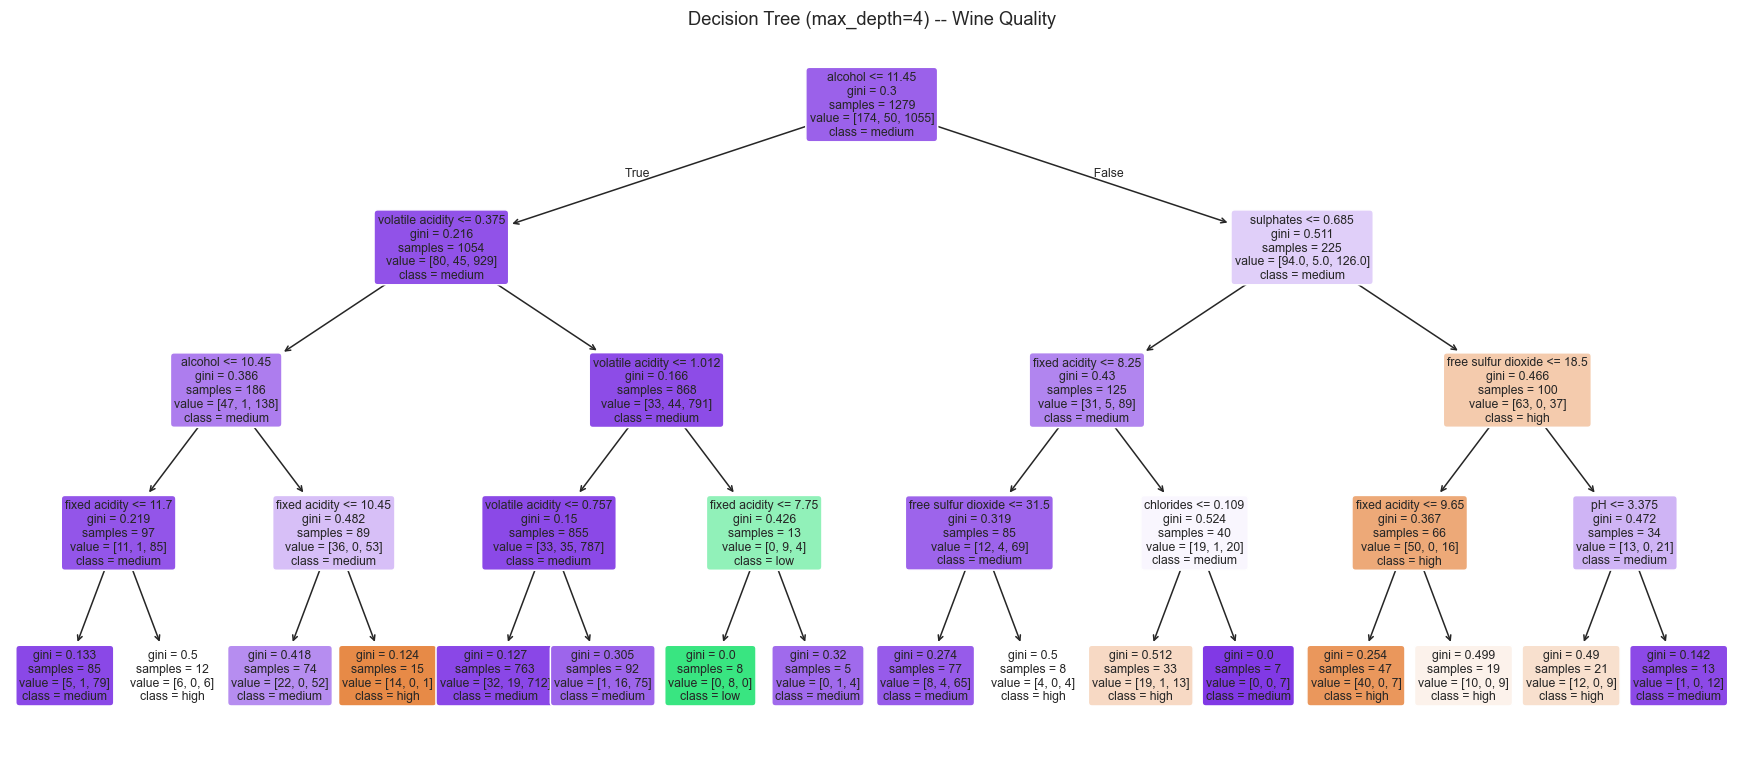

In [233]:
# Trees don't require scaling or one-hot encoding, so we can use the original X_train_multi and X_test_multi for training a Decision Tree classifier.

# TODO: Train a Decision Tree model for multi classification
model_tree_multi = DecisionTreeClassifier(max_depth=4, random_state=42)
model_tree_multi.fit(X_train_multi, y_train_multi)


# TODO: Predict and evaluate the Decision Tree model for multi classification
y_pred = model_tree_multi.predict(X_test_multi)
# TODO: Evaluate the model using accuracy score, confusion matrix and classification report


# TODO: Visualize the Decision Tree model using plot_tree
plt.figure(figsize=(16, 7))
plot_tree(model_tree_multi, feature_names=feature_cols, class_names=model_tree_multi.classes_,
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (max_depth=4) -- Wine Quality')
plt.tight_layout()
plt.show()


### Your Turn (Activity 2)

Compare the three multiclass models (2b, 2c, 2d) in one small table.

| Model | Test Accuracy |
|-------|---------------|
| Logistic Regression | ? |
| SVM (rbf) | ? |
| Decision Tree (depth=4) | ? |

Questions to discuss:
1. Which model did best overall?
2. Which class is hardest to predict? (look at the confusion matrices)
3. Try `DecisionTreeClassifier(max_depth=2)` and `max_depth=10`. What changes?


---
# Activity 3 -- Classification on AI Job Postings
Same three classification models as before, but on a slightly messier dataset where a bit of preprocessing is required.

**Shared context for Activities 3a-3c:**
- **Dataset:** `ai_job_dataset.csv` (15,000 AI/ML job postings)
- **Features (X):** `salary_usd`, `years_experience`, `remote_ratio`, `job_description_length`, `benefits_score`, `education_required`, `employment_type`, `company_size`
- **Target (y):** `experience_level` -- 4 classes: **EN** (entry), **MI** (mid), **SE** (senior), **EX** (executive)
- **Note:** categorical features must be encoded; this dataset is larger so models take slightly longer.


In [234]:
# load the AI job dataset
jobs = pd.read_csv('../../Datasets/ai_job_dataset.csv')

# Display basic information about the dataset
print('Shape:', jobs.shape)
print('\nExperience level distribution:')

# Display the distribution of experience levels in the dataset: ENTRY, MID, SENIOR, EXECUTIVE
print(jobs['experience_level'].value_counts())


display(jobs.head(3))


Shape: (15000, 19)

Experience level distribution:
experience_level
MI    3781
EX    3760
SE    3741
EN    3718
Name: count, dtype: int64


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech


In [235]:
# Select features and target: We will use only numeric features and not categorical features for this example

num_features = ['salary_usd', 'years_experience', 'remote_ratio',
                'job_description_length', 'benefits_score']

# Drop NA values and select only numeric features + target variable on the jobs dataset
jobs_subset = jobs[num_features + ['experience_level']].dropna()

# Create the feature matrix X_jobs and target vector y_jobs
X_jobs = jobs_subset[num_features]
y_jobs = jobs_subset['experience_level']

print(f'Feature matrix shape: {X_jobs.shape}')
print(f'Features: {list(X_jobs.columns)}')

# Train-test split for the jobs dataset
X_train_jobs, X_test_jobs, y_train_jobs, y_test_jobs = train_test_split(X_jobs, y_jobs, test_size=0.2,
                                                                    random_state=42, stratify=y_jobs)

# Scale the features for modeling
scaler = StandardScaler()
X_train_jobs_s = scaler.fit_transform(X_train_jobs)
X_test_jobs_s = scaler.transform(X_test_jobs)



Feature matrix shape: (15000, 5)
Features: ['salary_usd', 'years_experience', 'remote_ratio', 'job_description_length', 'benefits_score']


## Activity 3a -- Logistic Regression (Multiclass)

> ### Activity Card
> **Goal:** Predict job **experience level** (EN / MI / SE / EX) from the posting details.
> **Target (y):** `experience_level` (4 classes)
> **Task:** Fit `LogisticRegression` and report test accuracy + confusion matrix.


In [236]:
# TODO: Train a Logistic Regression model for multi classification on the jobs dataset


# TODO: Predict and evaluate the model using accuracy score, classification report and confusion matrix 



## Activity 3b -- SVM

> ### Activity Card
> **Goal:** Same 4-class problem, now with SVM.
> **Task:** Fit `SVC(kernel='rbf')` and report test accuracy.
> **Note:** SVM on 12,000 training rows may take ~30-60 seconds -- that's expected.


In [237]:
# TODO: Train a SVM model for multi classification on the jobs dataset


# TODO: Predict and evaluate the SVM model using accuracy score, classification report and confusion matrix

## Activity 3c -- Decision Tree

> ### Activity Card
> **Goal:** Same 4-class problem, now with a Decision Tree.
> **Task:** Fit `DecisionTreeClassifier(max_depth=6)`, report accuracy, list the top features.


In [238]:
# TODO: Train a Decision Tree model for multi classification on the jobs dataset


# TODO: Predict and evaluate the Decision Tree model using accuracy score, classification report and confusion matrix


# TODO: Visualize the feature importance of the Decision Tree model to understand which features are most important for predicting experience level


# TODO: Comapre the results of all models


### More Activity

1. Which model performs best on the AI jobs dataset?
2. Compared to Activity 2 (wine), are the accuracies higher or lower? Why might that be?
3. Look at the confusion matrix -- which two classes are most often confused (e.g. EN vs MI, or SE vs EX)? Does that make intuitive sense?
4. **Bonus:** Try dropping `salary_usd` from the features -- how much does accuracy drop? (that tells you how much of the signal was coming from salary alone).
